In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
import os


#styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
db = pd.read_parquet("RUL_FRMTM.parquet", engine="fastparquet")
db_plot = db.copy() 
non_na_rows = db[~db["System"].isna()]
na_rows = db[db["System"].isna()].sample(n=5000, random_state=42)  # Adjust 'n' as needed
db_sampled = pd.concat([non_na_rows, na_rows])
db_sampled.sort_values(by=["Date_Time", "EPISODE_ID"], inplace=True)
db=db_sampled.copy()

In [ ]:
def visualize_rul(df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    #RUL distribution
    axes[0,0].hist(df['RUL'], bins=50, edgecolor='black')
    axes[0,0].set_title('RUL Distribution')
    axes[0,0].set_xlabel('RUL')
    axes[0,0].set_ylabel('Frequency')
    
    #RUL by EPISODE_ID
    sample_episodes = df['EPISODE_ID'].value_counts().index[:10]
    for episode in sample_episodes:
        episode_data = df[df['EPISODE_ID'] == episode]
        axes[0,1].plot(episode_data['Date_Time'], episode_data['RUL'], 
                      label=f'Episode {episode}', alpha=0.7)
    axes[0,1].set_title('RUL Progression in Top 10 Episodes')
    axes[0,1].set_xlabel('Time')
    axes[0,1].set_ylabel('RUL')
    axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # RUL by Alarm_State
    if 'Alarm_State' in df.columns:
        sns.boxplot(data=df, x='Alarm_State', y='RUL', ax=axes[1,0])
        axes[1,0].set_title('RUL Distribution by Alarm State')
        axes[1,0].tick_params(axis='x', rotation=45)
    
    # RUL by System
    if 'System' in df.columns:
        top_systems = df['System'].value_counts().index[:5]
        system_df = df[df['System'].isin(top_systems)]
        sns.boxplot(data=system_df, x='System', y='RUL', ax=axes[1,1])
        axes[1,1].set_title('RUL Distribution by Top 5 Systems')
        axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def visualize_categorical(df):
    cat_cols = ['Alarm_State', 'Anomaly_Class', 'Class', 'Component', 'System']
    
    fig, axes = plt.subplots(3, 2, figsize=(15, 15))
    axes = axes.ravel()
    
    for idx, col in enumerate(cat_cols):
        if col in df.columns:
            top_cats = df[col].value_counts().head(10)
            axes[idx].bar(top_cats.index.astype(str), top_cats.values)
            axes[idx].set_title(f'Top 10 {col} Distribution')
            axes[idx].tick_params(axis='x', rotation=45)
            axes[idx].set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    if 'Alarm_State' in df.columns and 'Anomaly_Class' in df.columns:
        cross_tab = pd.crosstab(df['Alarm_State'], df['Anomaly_Class'])
        plt.figure(figsize=(10, 6))
        sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd')
        plt.title('Alarm State vs Anomaly Class')
        plt.show()

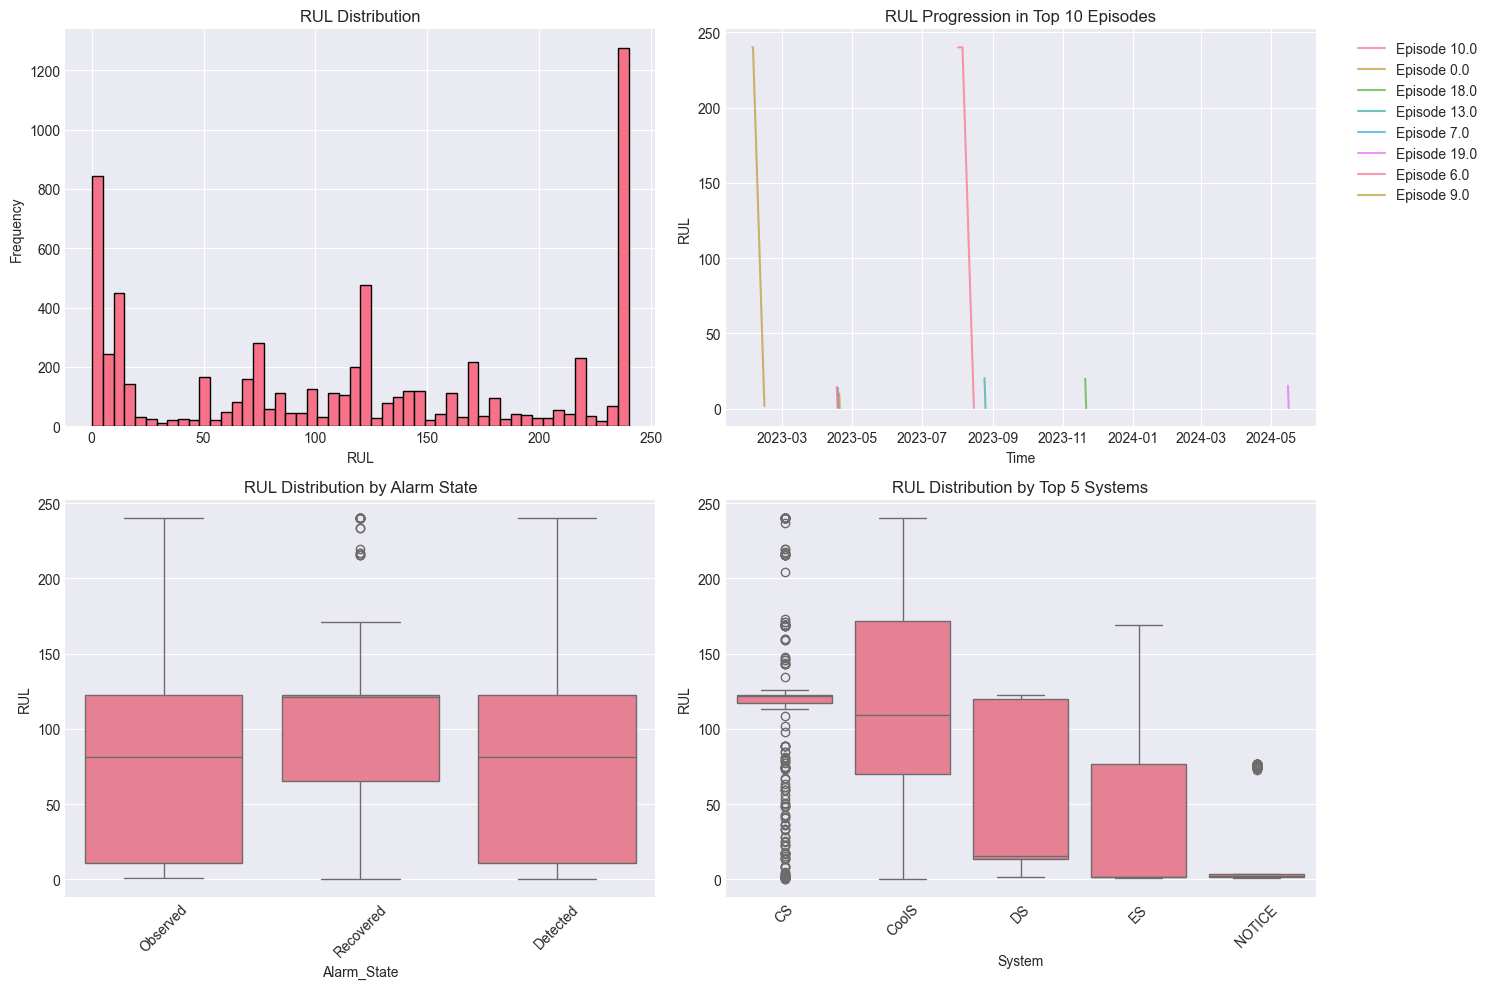

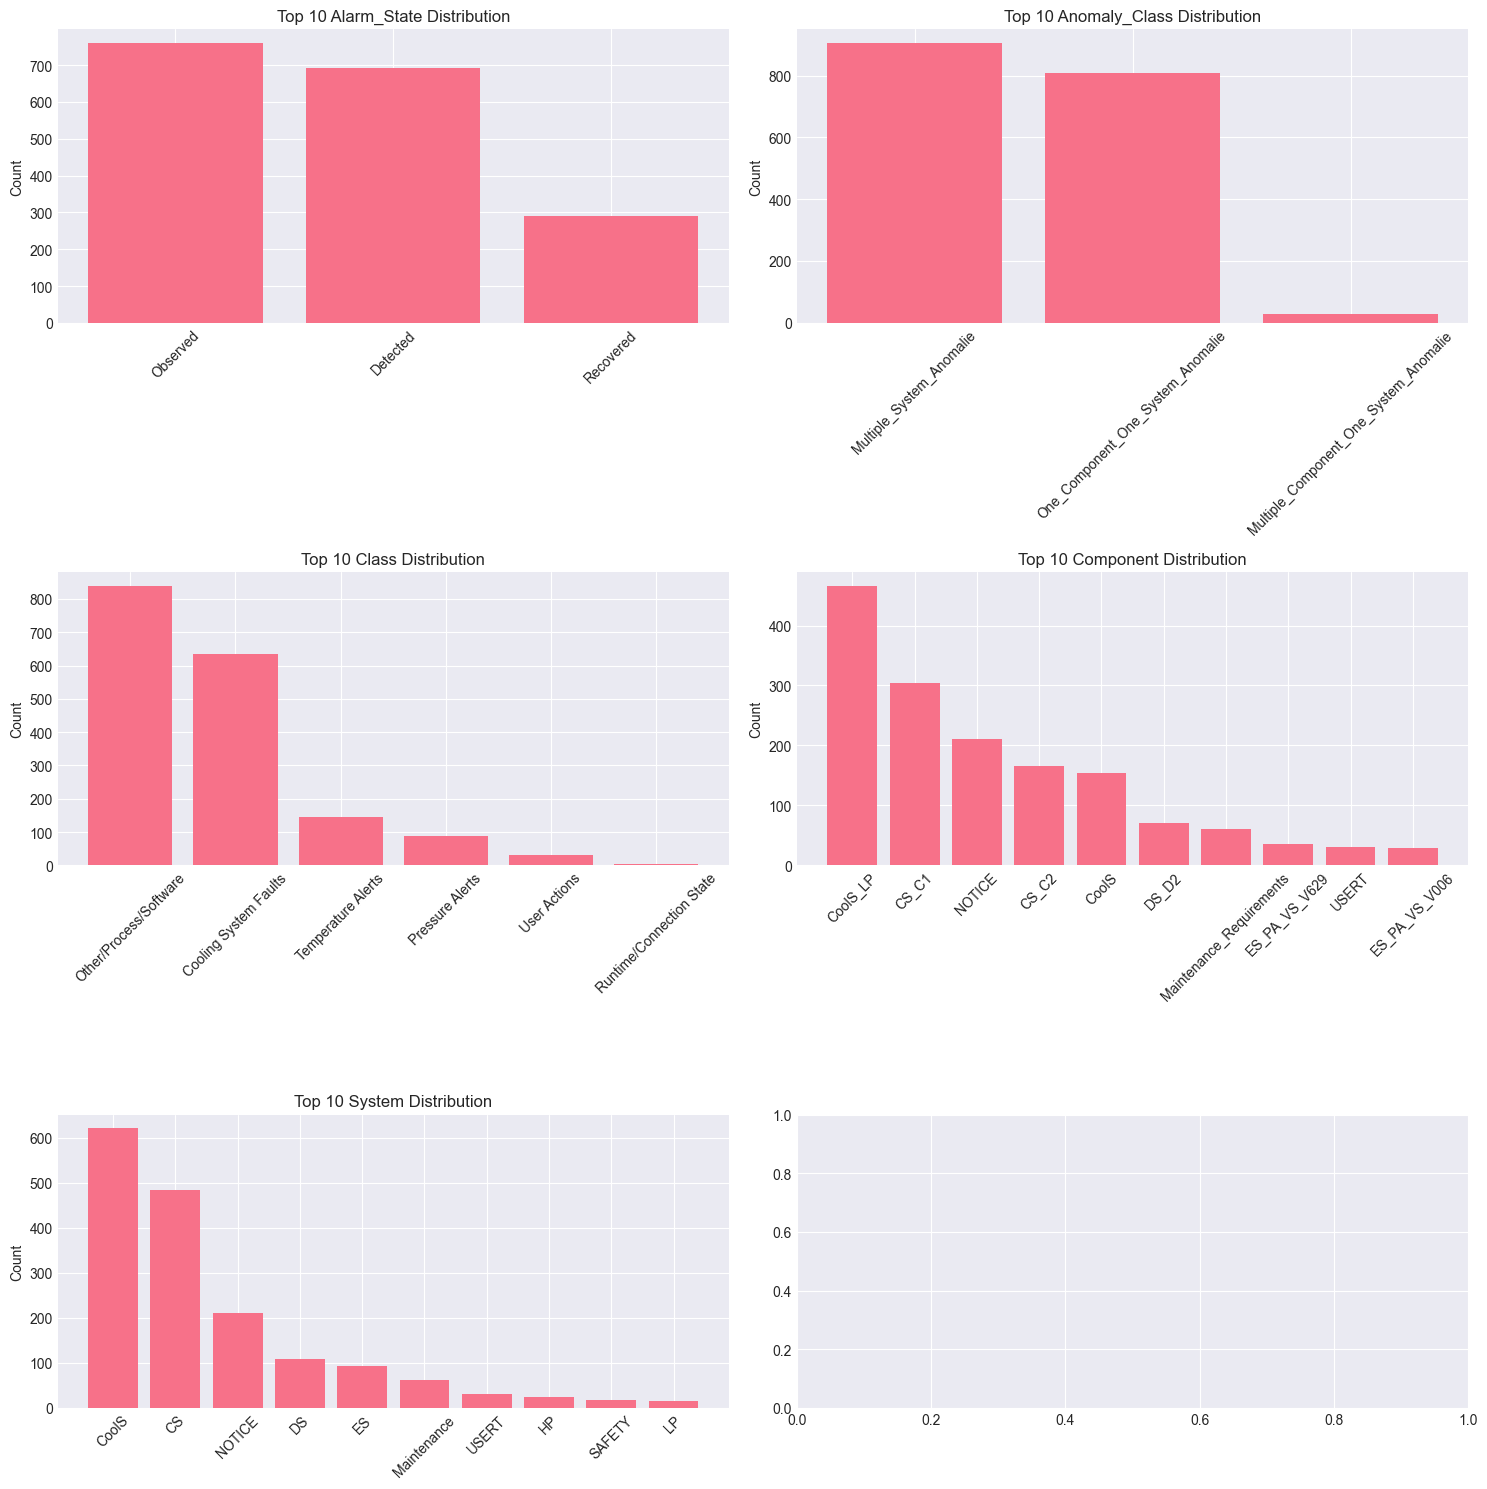

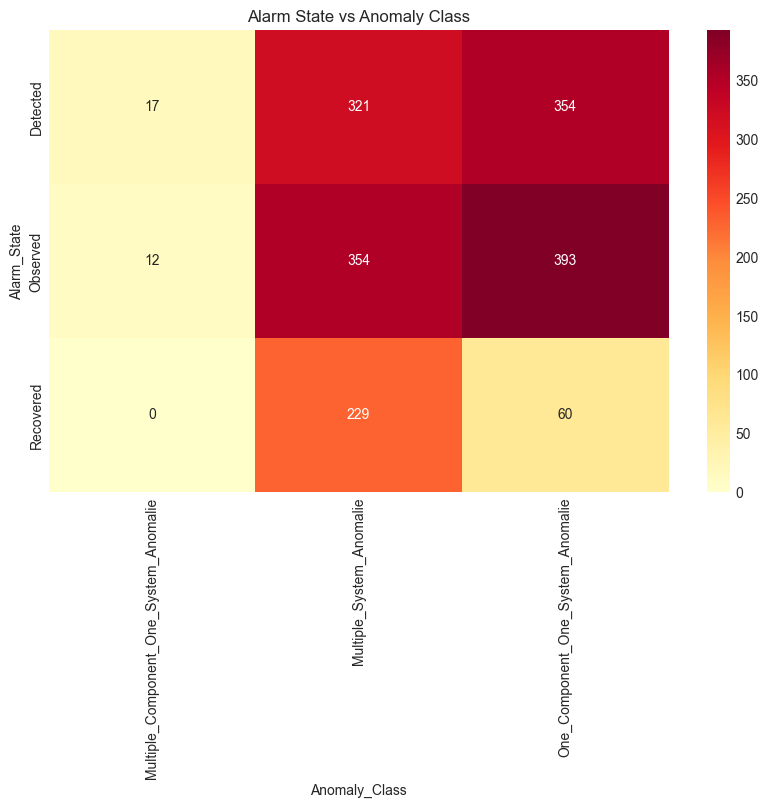

In [16]:
visualize_rul(db)
visualize_categorical(db)